# ZOS Transaction Data Analysis

End-to-end pipeline for the ZOS Nigerian banking transaction dataset (`dataset.csv`).

| Section | Description |
|---------|-------------|
| **1. Data Profiling** | Structural overview — dtypes, nulls, distributions, anomaly checks |
| **2. Data Cleaning** | Deduplication, validation, feature engineering, outlier flagging |
| **3. EDA** | Visualisations and summary statistics on cleaned data |

> **Dataset:** 5 M transactions (2023–2024), 15 columns — transaction metadata, NGN amounts/balances, channel, merchant, and location.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")

# --- Paths ---
DATA    = "dataset.csv"
CLEANED = "output/cleaned.csv"
OUT     = "output/"
SAMPLE_N = 500_000
FIGSIZE  = (12, 6)

os.makedirs(OUT, exist_ok=True)
print("Setup complete.")

Setup complete.


---
## 1. Data Profiling

A quick structural pass over the **raw** dataset before any cleaning.

In [2]:
df = pd.read_csv(DATA, parse_dates=["timestamp"])
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

Shape: 5,000,000 rows × 15 columns


### Data Types

In [3]:
df.dtypes

transaction_id                       str
account_id                           str
customer_id                          str
timestamp                 datetime64[us]
amount                           float64
balance_before_ngn               float64
balance_after_ngn                float64
transaction_type                     str
channel                              str
merchant_category_code           float64
merchant_name                        str
location_lga                         str
location_state                       str
device_id                            str
status                               str
dtype: object

### Null Counts & Percentages

In [4]:
nulls    = df.isnull().sum()
null_pct = (nulls / len(df) * 100).round(2)
null_df  = pd.DataFrame({"nulls": nulls, "pct_%": null_pct})
with_nulls = null_df[null_df["nulls"] > 0]
print(with_nulls.to_string() if len(with_nulls) else "No nulls found.")

                          nulls  pct_%
merchant_category_code  2998137  59.96
merchant_name           2998137  59.96
device_id               2750464  55.01


### Unique Value Counts

In [5]:
pd.DataFrame(
    {"unique_count": {col: df[col].nunique() for col in df.columns}}
)

,unique_count
transaction_id,5000000
account_id,100000
customer_id,100000
timestamp,848014
amount,27400
balance_before_ngn,5000000
balance_after_ngn,4653268
transaction_type,2
channel,7
merchant_category_code,14


### Numeric Summary Statistics

In [6]:
num_cols = df.select_dtypes(include="number").columns.tolist()
df[num_cols].describe().round(2)

,amount,balance_before_ngn,balance_after_ngn,merchant_category_code
count,5000000.00,5000000.00,5000000.00,2001863.00
mean,65621.99,336498.80,334980.25,5410.63
std,230311.87,452762.94,473451.41,507.88
min,100.00,4577.12,0.00,4814.00
25%,4000.00,86098.43,73019.20,4899.00
50%,13300.00,187949.88,183106.65,5411.00
75%,45000.00,402859.47,408644.07,5812.00
max,5000000.00,14879436.33,14820636.33,7523.00


### Categorical Value Counts (Top 10)

In [7]:
cat_cols = ["transaction_type", "channel", "status", "location_state", "merchant_category_code"]
for col in cat_cols:
    if col not in df.columns:
        continue
    print(f"\n--- {col} ---")
    vc = df[col].value_counts(dropna=False).head(10)
    for val, cnt in vc.items():
        print(f"  {val}: {cnt:,} ({cnt/len(df)*100:.1f}%)")


--- transaction_type ---
  debit: 3,250,541 (65.0%)
  credit: 1,749,459 (35.0%)

--- channel ---
  mobile: 1,749,043 (35.0%)
  pos: 1,501,370 (30.0%)
  atm: 999,469 (20.0%)
  web: 500,493 (10.0%)
  branch: 149,372 (3.0%)
  ussd: 75,336 (1.5%)
  agent: 24,917 (0.5%)

--- status ---
  success: 4,599,963 (92.0%)
  failed: 349,765 (7.0%)
  pending: 40,383 (0.8%)
  reversed: 9,889 (0.2%)

--- location_state ---
  Lagos: 1,225,836 (24.5%)
  Abuja (FCT): 542,759 (10.9%)
  Rivers: 446,381 (8.9%)
  Kano: 288,046 (5.8%)
  Anambra: 239,518 (4.8%)
  Oyo: 238,988 (4.8%)
  Imo: 186,312 (3.7%)
  Kaduna: 159,387 (3.2%)
  Delta: 135,097 (2.7%)
  Edo: 125,496 (2.5%)

--- merchant_category_code ---
  nan: 2,998,137 (60.0%)
  4814.0: 400,590 (8.0%)
  5411.0: 300,383 (6.0%)
  5812.0: 239,530 (4.8%)
  5541.0: 200,467 (4.0%)
  4900.0: 160,888 (3.2%)
  4899.0: 120,426 (2.4%)
  5999.0: 100,015 (2.0%)
  5814.0: 99,768 (2.0%)
  5651.0: 99,755 (2.0%)


### Duplicate Check

In [8]:
dup_txn   = df["transaction_id"].duplicated().sum()
full_dups = df.duplicated().sum()
print(f"Duplicate transaction_ids: {dup_txn:,}")
print(f"Fully duplicate rows:      {full_dups:,}")

Duplicate transaction_ids: 0
Fully duplicate rows:      0


### Timestamp Range

In [9]:
print(f"Min: {df['timestamp'].min()}")
print(f"Max: {df['timestamp'].max()}")

Min: 2023-01-01 00:07:00
Max: 2024-12-30 23:59:00


### Balance Consistency Check (Sample)

Verifies that `balance_after = balance_before ± amount` holds for a random sample of rows.

In [10]:
sample = df.sample(n=min(SAMPLE_N, len(df)), random_state=42)
debit  = sample[sample["transaction_type"] == "debit"]
credit = sample[sample["transaction_type"] == "credit"]

debit_ok  = ((debit["balance_before_ngn"]  - debit["amount"]  - debit["balance_after_ngn"]).abs()  < 0.01).mean()
credit_ok = ((credit["balance_before_ngn"] + credit["amount"] - credit["balance_after_ngn"]).abs() < 0.01).mean()

print(f"Debit balance consistent:  {debit_ok*100:.2f}%")
print(f"Credit balance consistent: {credit_ok*100:.2f}%")

Debit balance consistent:  89.34%
Credit balance consistent: 100.00%


### Anomaly Check

Looks for negative/zero amounts and negative balances.

In [11]:
print(f"Negative amounts:        {(df['amount'] < 0).sum():,}")
print(f"Negative balance_before: {(df['balance_before_ngn'] < 0).sum():,}")
print(f"Negative balance_after:  {(df['balance_after_ngn'] < 0).sum():,}")
print(f"Zero amounts:            {(df['amount'] == 0).sum():,}")

Negative amounts:        0
Negative balance_before: 0
Negative balance_after:  0
Zero amounts:            0


### Sample Rows

In [12]:
df.head(3)

,transaction_id,account_id,customer_id,timestamp,amount,balance_before_ngn,balance_after_ngn,transaction_type,channel,merchant_category_code,merchant_name,location_lga,location_state,device_id,status
0,42ae7cb0-052b-4c28-a149-8d7d2cc558a1,ACC-00000334,CUS-00000334,2024-09-14 14:59:00,2100.0,248561.187746,246461.187746,debit,web,4814.0,Airtel,Lagos LGA,Lagos,DEV-5b4184adc38945c2,failed
1,ce38456c-5bbb-4a83-992a-09e8fd59b49a,ACC-00004849,CUS-00004849,2024-12-26 01:54:00,73400.0,224711.795501,151311.795501,debit,web,5411.0,Grand Square,Benue LGA,Benue,DEV-b2b4b029db434254,success
2,9e69c19c-93c8-48fc-b2b8-e89d83b40936,ACC-00082189,CUS-00082189,2024-06-15 13:08:00,22600.0,114278.718868,136878.718868,credit,pos,7523.0,MegaPlaza Parking,Borno LGA,Borno,NaN,success


---
## 2. Data Cleaning

Cleans the raw dataset and engineers new features. The result is saved to `output/cleaned.csv`.

| Step | Action |
|------|--------|
| 1 | Drop fully duplicate rows |
| 2 | Drop duplicate `transaction_id`s (keep first) |
| 3 | Drop rows with invalid timestamps |
| 4 | Remove negative amounts |
| 5 | Flag balance-inconsistent rows |
| 6 | Standardise categorical columns (strip, lowercase) |
| 7 | Fill nulls in merchant and device fields |
| 8 | Extract time features from timestamp |
| 9 | Flag amount outliers (3× IQR fence) |
| 10 | Save to CSV |

In [13]:
df = pd.read_csv(DATA, parse_dates=["timestamp"])
n_orig = len(df)
print(f"Loaded: {df.shape}")

Loaded: (5000000, 15)


### Steps 1–2: Remove Duplicates

In [14]:
df = df.drop_duplicates()
print(f"After dropping full duplicates:           {len(df):,}  (removed {n_orig - len(df):,})")

n_before = len(df)
df = df.drop_duplicates(subset=["transaction_id"], keep="first")
print(f"After dropping duplicate transaction_ids: {len(df):,}  (removed {n_before - len(df):,})")

After dropping full duplicates:           5,000,000  (removed 0)
After dropping duplicate transaction_ids: 5,000,000  (removed 0)


### Step 3: Validate Timestamps

In [15]:
invalid_ts = df["timestamp"].isna().sum()
print(f"Invalid timestamps: {invalid_ts:,}")
if invalid_ts > 0:
    df = df.dropna(subset=["timestamp"])
    print(f"  Dropped rows with invalid timestamps. New length: {len(df):,}")
else:
    print("  All timestamps valid.")

Invalid timestamps: 0
  All timestamps valid.


### Step 4: Validate Amounts

In [16]:
neg_amt  = (df["amount"] < 0).sum()
zero_amt = (df["amount"] == 0).sum()
print(f"Negative amounts: {neg_amt:,}  |  Zero amounts: {zero_amt:,}")
if neg_amt > 0:
    df = df[df["amount"] >= 0]
    print(f"  Dropped negative amounts. New length: {len(df):,}")

Negative amounts: 0  |  Zero amounts: 0


### Step 5: Flag Balance Inconsistencies

Rows where `balance_after ≠ balance_before ± amount` are flagged with `balance_consistent = False` rather than dropped, so downstream analysis can still use or exclude them.

In [17]:
debit_mask  = df["transaction_type"] == "debit"
credit_mask = df["transaction_type"] == "credit"

debit_expected  = df.loc[debit_mask,  "balance_before_ngn"] - df.loc[debit_mask,  "amount"]
credit_expected = df.loc[credit_mask, "balance_before_ngn"] + df.loc[credit_mask, "amount"]

df["balance_consistent"] = True
df.loc[debit_mask,  "balance_consistent"] = (
    (df.loc[debit_mask,  "balance_after_ngn"] - debit_expected).abs()  < 0.01
)
df.loc[credit_mask, "balance_consistent"] = (
    (df.loc[credit_mask, "balance_after_ngn"] - credit_expected).abs() < 0.01
)

inconsistent = (~df["balance_consistent"]).sum()
print(f"Balance inconsistent rows: {inconsistent:,} ({inconsistent/len(df)*100:.2f}%)")

Balance inconsistent rows: 346,733 (6.93%)


### Step 6: Standardise Categorical Columns

Strip whitespace and convert to lowercase for consistency.

In [18]:
for col in ["transaction_type", "channel", "status", "location_state", "location_lga"]:
    df[col] = df[col].astype(str).str.strip().str.lower()
    df[col] = df[col].replace("nan", np.nan)

print(f"Transaction types: {df['transaction_type'].unique()}")
print(f"Channels:          {df['channel'].unique()}")
print(f"Statuses:          {df['status'].unique()}")

Transaction types: <ArrowStringArray>
['debit', 'credit']
Length: 2, dtype: str
Channels:          <ArrowStringArray>
['web', 'pos', 'mobile', 'branch', 'atm', 'ussd', 'agent']
Length: 7, dtype: str
Statuses:          <ArrowStringArray>
['failed', 'success', 'pending', 'reversed']
Length: 4, dtype: str


### Step 7: Handle Nulls in Merchant & Device Fields

- `merchant_name` / `merchant_category_code` — nulls are likely P2P or internal transfers → filled with `"unknown"` / `-1`
- `device_id` — nulls likely indicate POS/ATM without device tracking → filled with `"unknown"`

In [19]:
for col in ["merchant_name", "merchant_category_code", "device_id"]:
    n_null = df[col].isna().sum()
    print(f"Null {col}: {n_null:,} ({n_null/len(df)*100:.1f}%)")

df["merchant_name"]           = df["merchant_name"].fillna("unknown")
df["merchant_category_code"]  = df["merchant_category_code"].fillna(-1).astype(int)
df["device_id"]               = df["device_id"].fillna("unknown")
print("\nNulls filled.")

Null merchant_name: 2,998,137 (60.0%)
Null merchant_category_code: 2,998,137 (60.0%)
Null device_id: 2,750,464 (55.0%)

Nulls filled.


### Step 8: Extract Time Features

In [20]:
df["date"]        = df["timestamp"].dt.date
df["year"]        = df["timestamp"].dt.year
df["month"]       = df["timestamp"].dt.month
df["day"]         = df["timestamp"].dt.day
df["hour"]        = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.dayofweek   # 0 = Monday
df["is_weekend"]  = df["day_of_week"].isin([5, 6]).astype(int)

print("New columns:", ["date", "year", "month", "day", "hour", "day_of_week", "is_weekend"])

New columns: ['date', 'year', 'month', 'day', 'hour', 'day_of_week', 'is_weekend']


### Step 9: Flag Amount Outliers

Conservative 3× IQR fence — flags extreme transaction amounts without dropping them.

In [21]:
Q1 = df["amount"].quantile(0.25)
Q3 = df["amount"].quantile(0.75)
upper_fence = Q3 + 3 * (Q3 - Q1)

df["amount_outlier"] = (df["amount"] > upper_fence).astype(int)
print(f"Upper fence (3× IQR): {upper_fence:,.0f} NGN")
print(f"Outliers flagged:     {df['amount_outlier'].sum():,}")

Upper fence (3× IQR): 168,000 NGN
Outliers flagged:     398,964


### Step 10: Save Cleaned Dataset

In [22]:
print(f"Final shape: {df.shape}")
df.to_csv(CLEANED, index=False)
print(f"Saved → {CLEANED}")

Final shape: (5000000, 24)
Saved → output/cleaned.csv


---
## 3. Exploratory Data Analysis (EDA)

Visual exploration of the cleaned dataset. Plots are rendered inline **and** saved to `output/`.

In [23]:
df = pd.read_csv(CLEANED, parse_dates=["timestamp"])
print(f"Loaded cleaned data: {df.shape}")

Loaded cleaned data: (5000000, 24)


### Plot 1: Monthly Transaction Volume & Amount

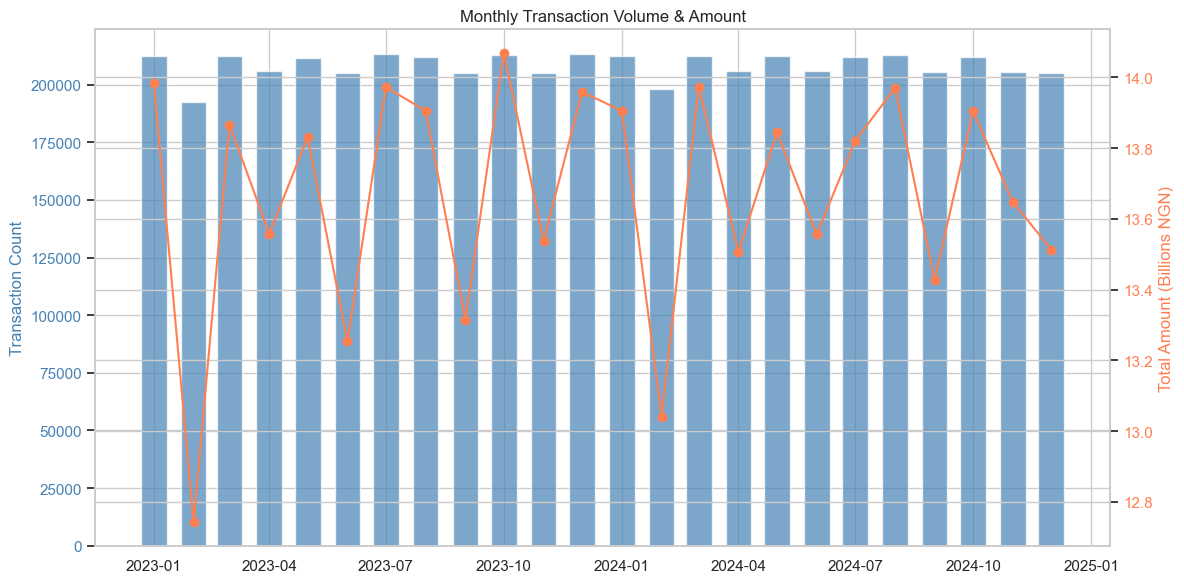

In [24]:
monthly = df.groupby(df["timestamp"].dt.to_period("M")).agg(
    txn_count   =("transaction_id", "count"),
    total_amount=("amount", "sum"),
    avg_amount  =("amount", "mean"),
).reset_index()
monthly["timestamp"] = monthly["timestamp"].dt.to_timestamp()

fig, ax1 = plt.subplots(figsize=FIGSIZE)
ax1.bar(monthly["timestamp"], monthly["txn_count"], width=20, alpha=0.7, color="steelblue")
ax1.set_ylabel("Transaction Count", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")
ax2 = ax1.twinx()
ax2.plot(monthly["timestamp"], monthly["total_amount"] / 1e9, color="coral", marker="o")
ax2.set_ylabel("Total Amount (Billions NGN)", color="coral")
ax2.tick_params(axis="y", labelcolor="coral")
plt.title("Monthly Transaction Volume & Amount")
fig.tight_layout()
plt.savefig(f"{OUT}01_monthly_volume.png", dpi=150)
plt.show()

### Plot 2: Transaction Type & Status Distribution

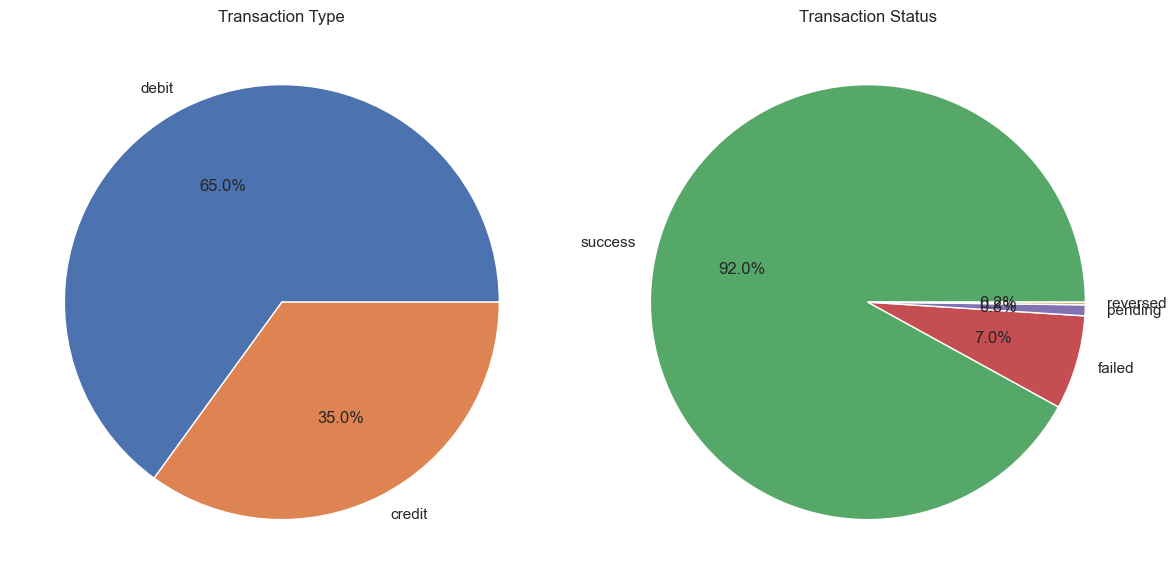

In [25]:
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)
df["transaction_type"].value_counts().plot.pie(
    autopct="%1.1f%%", ax=axes[0], colors=["#4C72B0", "#DD8452"]
)
axes[0].set_title("Transaction Type")
axes[0].set_ylabel("")
df["status"].value_counts().plot.pie(
    autopct="%1.1f%%", ax=axes[1], colors=["#55A868", "#C44E52", "#8172B2", "#CCB974"]
)
axes[1].set_title("Transaction Status")
axes[1].set_ylabel("")
plt.tight_layout()
plt.savefig(f"{OUT}02_type_status_dist.png", dpi=150)
plt.show()

### Plot 3: Channel Distribution

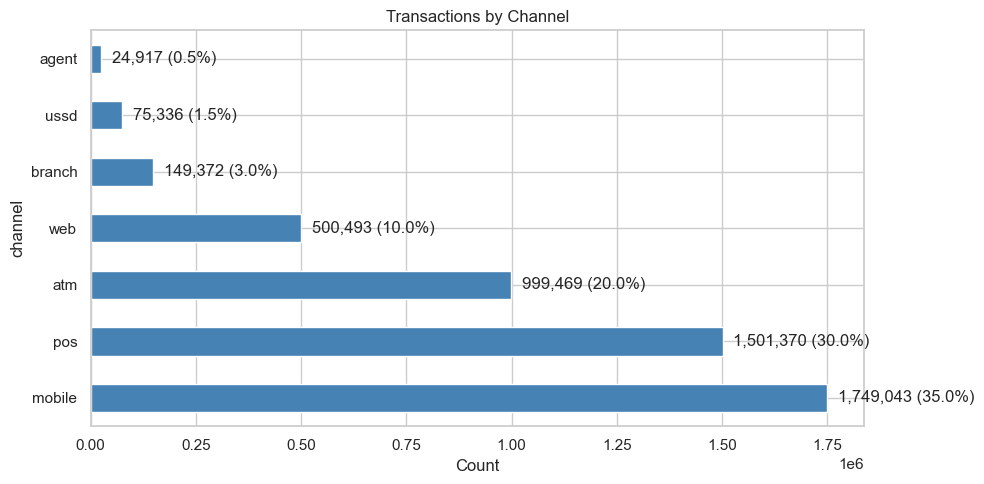

In [26]:
fig, ax = plt.subplots(figsize=(10, 5))
ch_counts = df["channel"].value_counts()
ch_counts.plot.barh(ax=ax, color="steelblue")
for i, (val, cnt) in enumerate(ch_counts.items()):
    ax.text(cnt + len(df) * 0.005, i, f"{cnt:,} ({cnt/len(df)*100:.1f}%)", va="center")
ax.set_title("Transactions by Channel")
ax.set_xlabel("Count")
plt.tight_layout()
plt.savefig(f"{OUT}03_channel_dist.png", dpi=150)
plt.show()

### Plot 4: Amount Distribution

Left: raw distribution clipped at 99th percentile. Right: log₁₀ scale to show spread across orders of magnitude.

/var/folders/31/cpdt29996j31tk6_htk2vqx40000gn/T/ipykernel_30245/2060444919.py:13: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/31/cpdt29996j31tk6_htk2vqx40000gn/T/ipykernel_30245/2060444919.py:13: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/31/cpdt29996j31tk6_htk2vqx40000gn/T/ipykernel_30245/2060444919.py:14: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.savefig(f"{OUT}04_amount_dist.png", dpi=150)
/var/folders/31/cpdt29996j31tk6_htk2vqx40000gn/T/ipykernel_30245/2060444919.py:14: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.savefig(f"{OUT}04_amount_dist.png", dpi=150)
/Users/tashi/Desktop/misc/zos/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/tashi/Desktop/mi

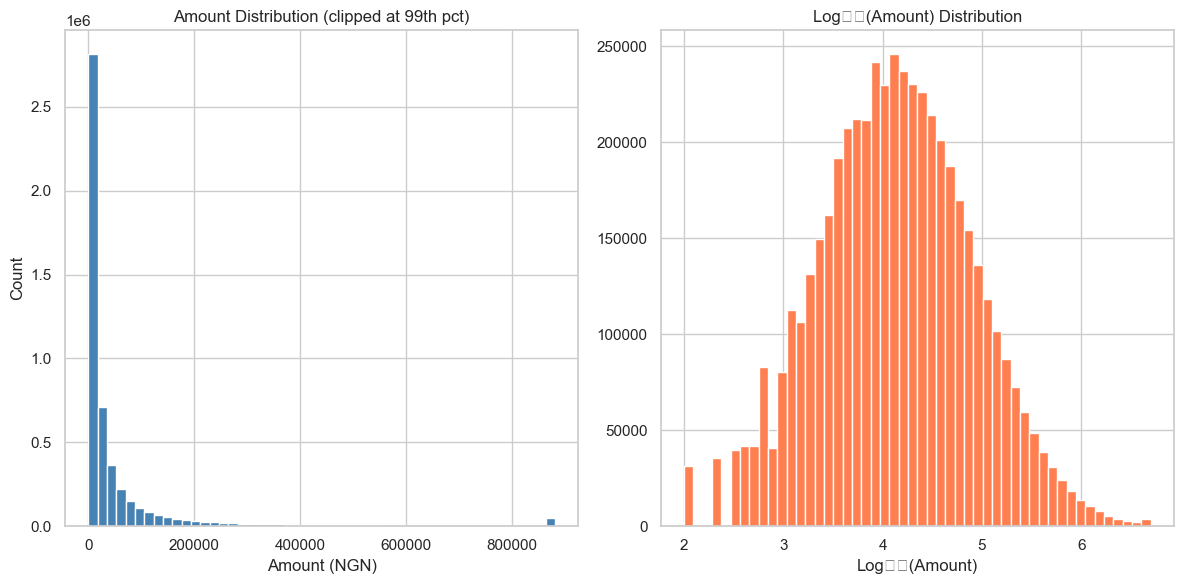

In [27]:
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)
df["amount"].clip(upper=df["amount"].quantile(0.99)).hist(
    bins=50, ax=axes[0], color="steelblue", edgecolor="white"
)
axes[0].set_title("Amount Distribution (clipped at 99th pct)")
axes[0].set_xlabel("Amount (NGN)")
axes[0].set_ylabel("Count")
df["amount"][df["amount"] > 0].apply(np.log10).hist(
    bins=50, ax=axes[1], color="coral", edgecolor="white"
)
axes[1].set_title("Log₁₀(Amount) Distribution")
axes[1].set_xlabel("Log₁₀(Amount)")
plt.tight_layout()
plt.savefig(f"{OUT}04_amount_dist.png", dpi=150)
plt.show()

### Plot 5: Hourly Transaction Pattern

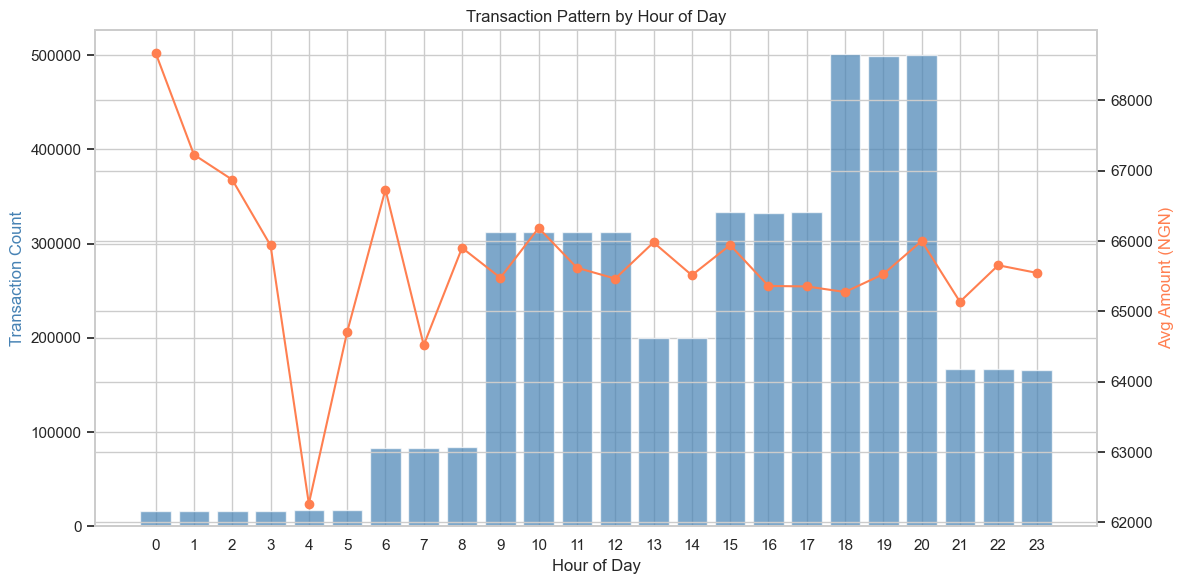

In [28]:
hourly = df.groupby("hour").agg(
    count  =("transaction_id", "count"),
    avg_amt=("amount", "mean")
).reset_index()

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.bar(hourly["hour"], hourly["count"], color="steelblue", alpha=0.7)
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Transaction Count", color="steelblue")
ax.set_xticks(range(24))
ax2 = ax.twinx()
ax2.plot(hourly["hour"], hourly["avg_amt"], color="coral", marker="o")
ax2.set_ylabel("Avg Amount (NGN)", color="coral")
ax.set_title("Transaction Pattern by Hour of Day")
plt.tight_layout()
plt.savefig(f"{OUT}05_hourly_pattern.png", dpi=150)
plt.show()

### Plot 6: Day-of-Week Pattern

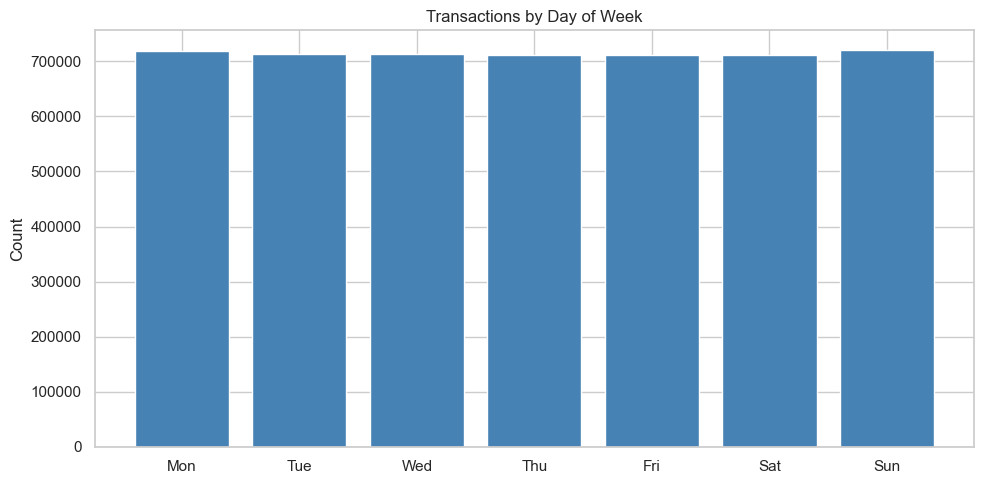

In [29]:
dow_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
dow = df.groupby("day_of_week").agg(count=("transaction_id", "count")).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(dow["day_of_week"], dow["count"], color="steelblue")
ax.set_xticks(range(7))
ax.set_xticklabels(dow_labels)
ax.set_title("Transactions by Day of Week")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig(f"{OUT}06_dow_pattern.png", dpi=150)
plt.show()

### Plot 7: Top 15 States by Transaction Count

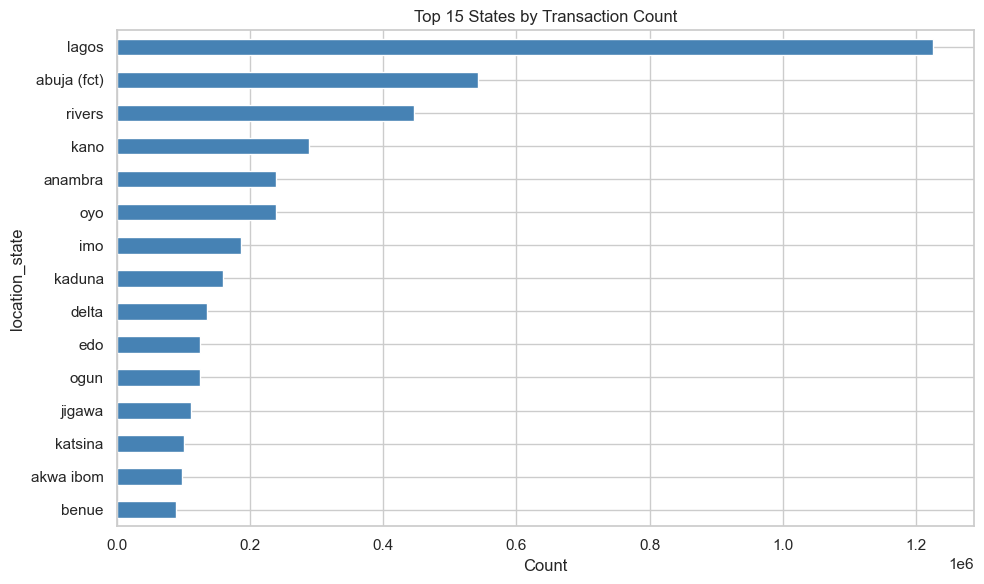

In [30]:
fig, ax = plt.subplots(figsize=(10, 6))
top_states = df["location_state"].value_counts().head(15)
top_states.plot.barh(ax=ax, color="steelblue")
ax.set_title("Top 15 States by Transaction Count")
ax.set_xlabel("Count")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(f"{OUT}07_top_states.png", dpi=150)
plt.show()

### Plot 8: Top 15 Merchants by Transaction Count

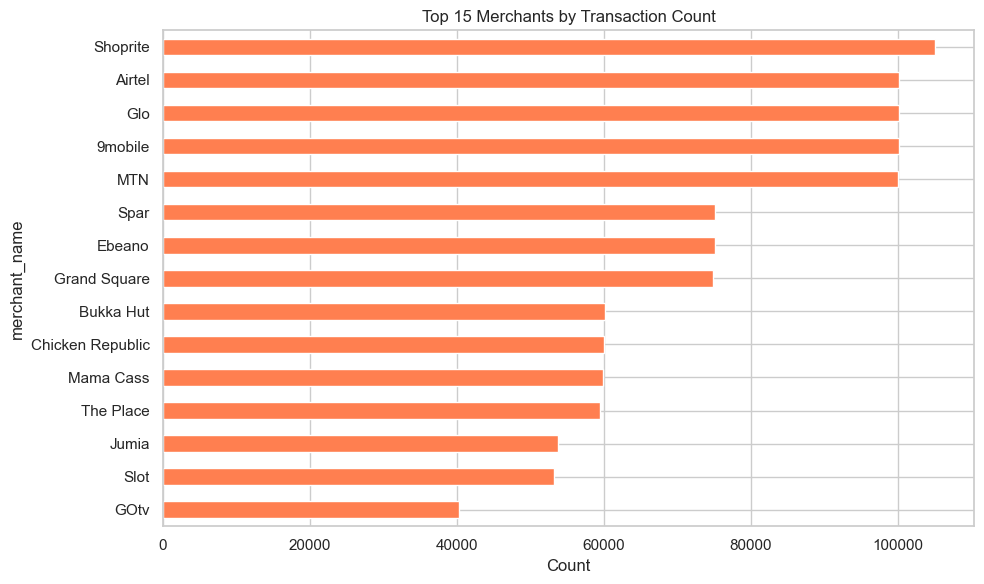

In [31]:
fig, ax = plt.subplots(figsize=(10, 6))
top_merch = df[df["merchant_name"] != "unknown"]["merchant_name"].value_counts().head(15)
top_merch.plot.barh(ax=ax, color="coral")
ax.set_title("Top 15 Merchants by Transaction Count")
ax.set_xlabel("Count")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(f"{OUT}08_top_merchants.png", dpi=150)
plt.show()

### Plot 9: Customer Activity Distribution

Left: how many transactions each customer made. Right: total spend per customer. Both clipped at 99th percentile.

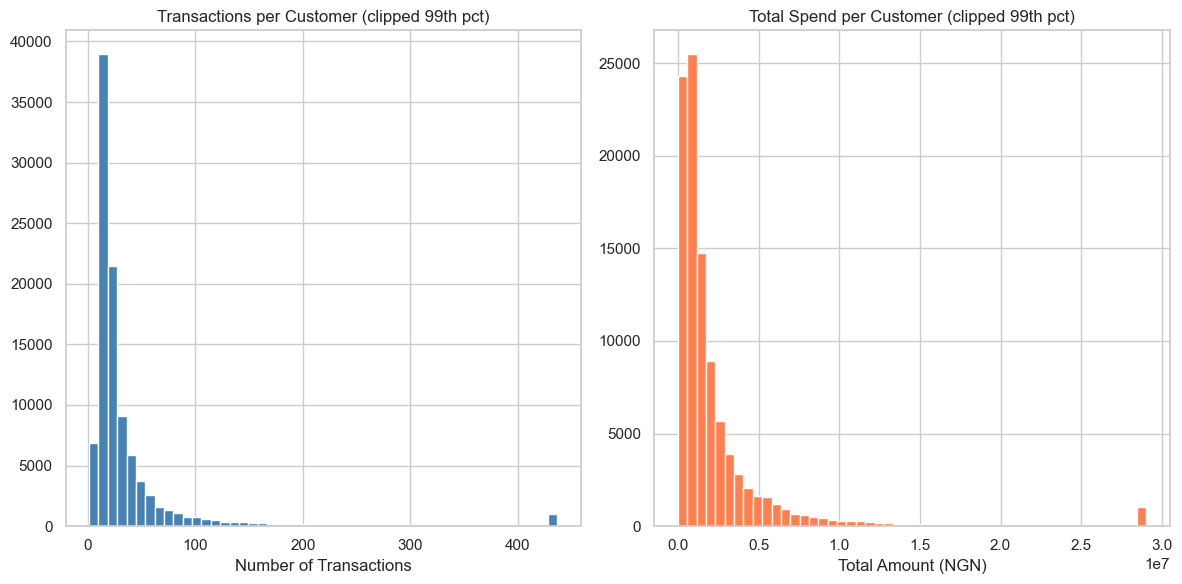

In [32]:
cust_txn = df.groupby("customer_id").size()
cust_amt = df.groupby("customer_id")["amount"].sum()

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)
cust_txn.clip(upper=cust_txn.quantile(0.99)).hist(
    bins=50, ax=axes[0], color="steelblue", edgecolor="white"
)
axes[0].set_title("Transactions per Customer (clipped 99th pct)")
axes[0].set_xlabel("Number of Transactions")
cust_amt.clip(upper=cust_amt.quantile(0.99)).hist(
    bins=50, ax=axes[1], color="coral", edgecolor="white"
)
axes[1].set_title("Total Spend per Customer (clipped 99th pct)")
axes[1].set_xlabel("Total Amount (NGN)")
plt.tight_layout()
plt.savefig(f"{OUT}09_customer_activity.png", dpi=150)
plt.show()

### Plot 10: Failed Transaction Analysis

Left: failure rate by channel. Right: failure rate by hour of day.

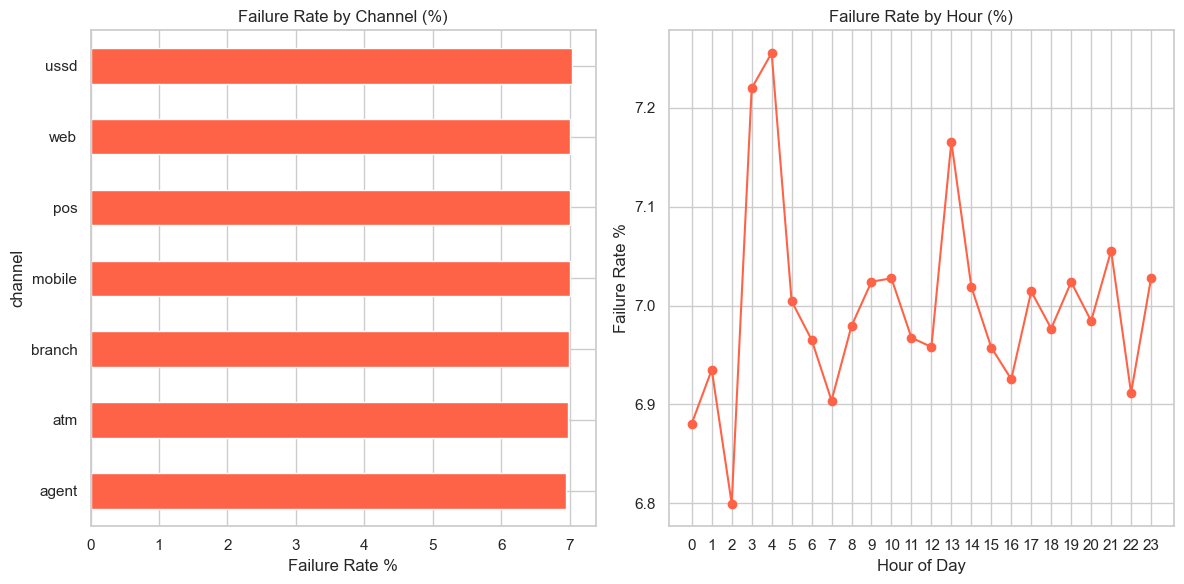

In [33]:
fail_by_channel = df.groupby("channel")["status"].apply(lambda x: (x == "failed").mean() * 100)
fail_by_hour    = df.groupby("hour")["status"].apply(lambda x: (x == "failed").mean() * 100)

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)
fail_by_channel.sort_values().plot.barh(ax=axes[0], color="tomato")
axes[0].set_title("Failure Rate by Channel (%)")
axes[0].set_xlabel("Failure Rate %")
axes[1].plot(fail_by_hour.index, fail_by_hour.values, marker="o", color="tomato")
axes[1].set_title("Failure Rate by Hour (%)")
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("Failure Rate %")
axes[1].set_xticks(range(24))
plt.tight_layout()
plt.savefig(f"{OUT}10_failed_txn_analysis.png", dpi=150)
plt.show()

### Summary Statistics

In [34]:
summary = {
    "Total transactions":          f"{len(df):,}",
    "Unique customers":            f"{df['customer_id'].nunique():,}",
    "Unique accounts":             f"{df['account_id'].nunique():,}",
    "Date range":                  f"{df['timestamp'].min()} → {df['timestamp'].max()}",
    "Total amount (NGN)":          f"{df['amount'].sum():,.0f}",
    "Median amount (NGN)":         f"{df['amount'].median():,.0f}",
    "Mean amount (NGN)":           f"{df['amount'].mean():,.0f}",
    "Max amount (NGN)":            f"{df['amount'].max():,.0f}",
    "Avg txns per customer":       f"{len(df)/df['customer_id'].nunique():.1f}",
    "Balance inconsistent rows":   f"{(~df['balance_consistent']).sum():,}",
    "Amount outlier rows":         f"{df['amount_outlier'].sum():,}",
}

pd.DataFrame.from_dict(summary, orient="index", columns=["Value"])

,Value
Total transactions,"5,000,000"
Unique customers,"100,000"
Unique accounts,"100,000"
Date range,2023-01-01 00:07:00 → 2024-12-30 23:59:00
Total amount (NGN),"328,109,942,600"
Median amount (NGN),"13,300"
Mean amount (NGN),"65,622"
Max amount (NGN),"5,000,000"
Avg txns per customer,50.0
Balance inconsistent rows,"346,733"
